# Set Folder to save the models

In [7]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent

DATA_DIR     = PROJECT_ROOT / "data"
MODEL_DIR    = PROJECT_ROOT / "models"
GRAPHICS_DIR = PROJECT_ROOT / "graphics"

MODEL_DIR.mkdir(exist_ok=True)
GRAPHICS_DIR.mkdir(exist_ok=True)

# Load datasets and merge them into one dataframe

In [8]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", module="statsmodels")



DGS1 = pd.read_csv('../data/DGS1.csv')  
DGS2 = pd.read_csv('../data/DGS2.csv')
DGS5 = pd.read_csv('../data/DGS5.csv')
DGS10 = pd.read_csv('../data/DGS10.csv')    


merged = DGS2.merge(DGS5, on="observation_date", how="inner").merge(DGS10, on="observation_date", how="inner") 
merged = merged.dropna(subset=["DGS2","DGS5","DGS10"])

merged = merged.set_index("observation_date") 
merged.index = pd.to_datetime(merged.index, errors="coerce") 

DGS1 = DGS1.dropna(subset=["DGS1"]) 

DGS1 = DGS1.set_index("observation_date") 
DGS1.index = pd.to_datetime(DGS1.index, errors="coerce") 

viz_merged = merged.merge(DGS1, left_index=True, right_index=True, how="inner")


In [5]:
viz_merged.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4227 entries, 2009-01-02 to 2025-11-25
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DGS2    4227 non-null   float64
 1   DGS5    4227 non-null   float64
 2   DGS10   4227 non-null   float64
 3   DGS1    4227 non-null   float64
dtypes: float64(4)
memory usage: 165.1 KB


# Preprocessing summary

-Loaded raw FRED CSVs (DGS1.csv, DGS2.csv, DGS5.csv, DGS10.csv) and inspected shapes/dtypes. We saw 4408 entries of which 4227 were non-null

-Merged the three series on the common key observation_date using an inner join.

-Dropped rows with missing yields in any of DGS2, DGS5, DGS10 (missing days are typically U.S. market holidays or occasional gaps) leaving us with the 4227 entries from before

-Converted observation_date to proper datetime and set it as the index to enable clean time-series operations

# Vizualizing the Dataset

In [3]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go


data = viz_merged.dropna()
maturities = np.array([1, 2, 5, 10])
years = data.index.year + (data.index.dayofyear - 1) / 365
X_mesh, Y_mesh = np.meshgrid(years, maturities)
Z = data[["DGS1", "DGS2", "DGS5", "DGS10"]].T.values 


fig = go.Figure(data=[
    go.Surface(
        x=X_mesh,
        y=Y_mesh,
        z=Z,
        colorscale='Viridis',
        colorbar=dict(title='Yield (%)')
    )
])

fig.update_layout(
    title='U.S. Treasury Yield Curves (2009–2025)',
    scene=dict(
        xaxis_title='Year',
        yaxis_title='Maturity (years)',
        zaxis_title='Yield (%)'
    ),
    width=1200,
    height=900
)

fig.show()


# Descriptive Statistics

In [4]:
import pandas as pd
import numpy as np


yields = viz_merged[["DGS1", "DGS2", "DGS5", "DGS10"]].dropna()

desc = pd.DataFrame({
    "Mean":      yields.mean(),
    "Median":    yields.median(),
    "Std. dev.": yields.std(),
    "Min":       yields.min(),
    "Max":       yields.max(),
    "Skew":      yields.skew(),
    "Kurt":      yields.kurt()   
})


desc.index = ["1-year", "2-year", "5-year", "10-year"]
desc = desc.round(2)

print(desc)


         Mean  Median  Std. dev.   Min   Max  Skew  Kurt
1-year   1.45    0.49       1.70  0.04  5.49  1.11 -0.24
2-year   1.57    0.88       1.50  0.09  5.19  1.00 -0.43
5-year   2.06    1.75       1.16  0.19  4.95  0.64 -0.57
10-year  2.64    2.53       0.99  0.52  4.98  0.20 -0.66


# Define Train and Test Periods and calculate the amount of observations in each

In [9]:
idx = merged.index

# Proposed split dates
train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-25")  

train_days = ((idx >= train_start) & (idx <= train_end)).sum()
test_days  = ((idx >= test_start) & (idx <= test_end)).sum()

print("\nTRAINING DAYS:", train_days)
print("TEST DAYS:    ", test_days)



TRAINING DAYS: 2501
TEST DAYS:     1726


# Randomw Walk Benchmark

Random Walk performance (test period only):


RMSE  Mean_Error  Std_Error  N_Forecasts
Maturity Horizon                                              
DGS10    1        0.058991    0.000765   0.059003         1726
         5        0.126820    0.003830   0.126799         1726
         10       0.179106    0.007625   0.178996         1726
         30       0.326972    0.020029   0.326452         1726
DGS2     1        0.061234    0.000550   0.061250         1726
         5        0.131264    0.002787   0.131273         1726
         10       0.188553    0.005487   0.188528         1726
         30       0.357070    0.013957   0.356901         1726
DGS5     1        0.062582    0.000603   0.062597         1726
         5        0.134244    0.003042   0.134249         1726
         10       0.189948    0.006112   0.189905         1726
         30       0.348277    0.015608   0.348028         1726

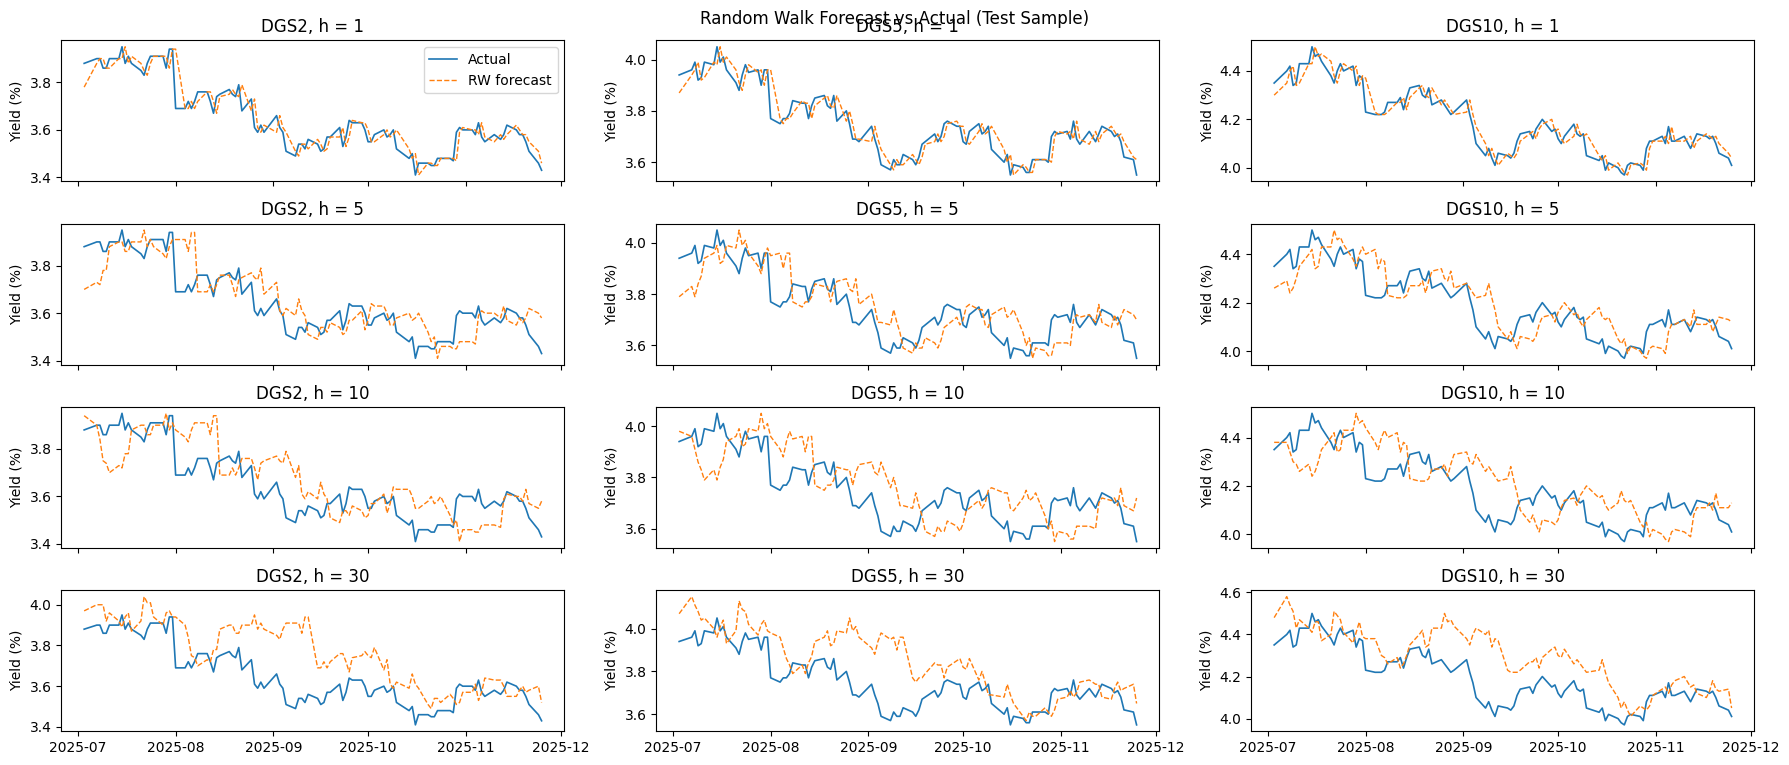

Saved RW model to models/RW.pkl


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-25")

# merged: DataFrame with DGS2, DGS5, DGS10 as columns, DateTimeIndex
merged = merged.sort_index()

# ----------- Random Walk forecast (index = forecast date t+h) -------------
results = []
rw_predictions = {}   # (maturity, h) -> Series of forecasts y_hat_{t+h|t}, index = t+h
rw_actuals     = {}   # (maturity, h) -> Series of actual y_{t+h},   index = t+h

for col in maturity_cols:
    y = merged[col]

    for h in horizons:
        # RW logic:
        #   actual at forecast date f = y_f
        #   forecast at forecast date f = y_{f-h}  (i.e. y_t, t = f-h)
        actual = y.copy()
        forecast = y.shift(h)   # at index f, value y_{f-h}

        # Build joint frame and restrict to evaluation window on FORECAST DATES
        df = pd.DataFrame({"actual": actual, "forecast": forecast})
        df = df.loc[(df.index >= test_start) & (df.index <= test_end)].dropna()

        if df.empty:
            continue

        errors = df["actual"] - df["forecast"]

        rmse = np.sqrt(np.mean(errors**2))
        mean_err = errors.mean()
        std_err = errors.std(ddof=1)

        results.append({
            "Maturity": col,
            "Horizon": h,
            "RMSE": rmse,
            "Mean_Error": mean_err,
            "Std_Error": std_err,
            "N_Forecasts": len(errors)
        })

        # Store series with index = forecast date (t+h), consistent with other models
        rw_predictions[(col, h)] = df["forecast"]
        rw_actuals[(col, h)]     = df["actual"]

# ------------ Results table ---------------
rw_results_df = pd.DataFrame(results)
rw_results_df = rw_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("Random Walk performance (test period only):")
display(rw_results_df)

# ------------------ Visualization ------------------
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 8),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]
        key = (col, h)

        if key not in rw_actuals:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = rw_actuals[key]
        pred_series   = rw_predictions[key]

        N = 100
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="RW forecast",
                linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Random Walk Forecast vs Actual (Test Sample)", y=0.95)
plt.tight_layout()
plt.show()

# --- Naming convention for downstream use ---
rw_pred_series   = rw_predictions
rw_actual_series = rw_actuals

rw_bundle = {
    "predictions": rw_predictions,
    "actuals": rw_actuals,
    "metrics": rw_results_df
}

with open(MODEL_DIR / "RW.pkl", "wb") as f:
    pickle.dump(rw_bundle, f)

print("Saved RW model to models/RW.pkl")


Our results are as expected.

-Increasing Maturity reduces the RMSE -> more persistence in longer yields

-Increasing forecast horizons increases the RMSE -> more volatility over long periods

-Maturities are ordered DGS2 > DGS 5 > DGS 10 -> longer yields, more persistence

# Implement the Dynamic Nelson Siegel Model

[SANITY] DNS cross-sectional reconstruction RMSE (all sample, all maturities): 0.000000

=== Running DNS VAR(1) forecasts for horizon h = 1 ===


c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequ


=== Running DNS VAR(1) forecasts for horizon h = 5 ===


c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequ


=== Running DNS VAR(1) forecasts for horizon h = 10 ===


...


=== Running DNS VAR(1) forecasts for horizon h = 30 ===


c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequ


=== Safety log (first 5 forecasts per horizon) ===

Horizon h = 1:
  origin: 2019-01-02, forecast: 2019-01-03, train_size: 2502
  origin: 2019-01-03, forecast: 2019-01-04, train_size: 2503
  origin: 2019-01-04, forecast: 2019-01-07, train_size: 2504
  origin: 2019-01-07, forecast: 2019-01-08, train_size: 2505
  origin: 2019-01-08, forecast: 2019-01-09, train_size: 2506

Horizon h = 5:
  origin: 2019-01-02, forecast: 2019-01-09, train_size: 2502
  origin: 2019-01-03, forecast: 2019-01-10, train_size: 2503
  origin: 2019-01-04, forecast: 2019-01-11, train_size: 2504
  origin: 2019-01-07, forecast: 2019-01-14, train_size: 2505
  origin: 2019-01-08, forecast: 2019-01-15, train_size: 2506

Horizon h = 10:
  origin: 2019-01-02, forecast: 2019-01-16, train_size: 2502
  origin: 2019-01-03, forecast: 2019-01-17, train_size: 2503
  origin: 2019-01-04, forecast: 2019-01-18, train_size: 2504
  origin: 2019-01-07, forecast: 2019-01-22, train_size: 2505
  origin: 2019-01-08, forecast: 2019-01-23, t

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequ

RMSE  Mean_Error  Std_Error  N_Forecasts
Maturity Horizon                                              
DGS10    1        0.059081    0.000113   0.059098         1725
         5        0.127669    0.000720   0.127704         1721
         10       0.181670    0.001404   0.181718         1716
         30       0.338187    0.003590   0.338268         1696
DGS2     1        0.061312   -0.000139   0.061329         1725
         5        0.131994   -0.000475   0.132031         1721
         10       0.190579   -0.000846   0.190632         1716
         30       0.366263   -0.003018   0.366359         1696
DGS5     1        0.062685    0.000124   0.062703         1725
         5        0.135193    0.000850   0.135230         1721
         10       0.192971    0.001753   0.193019         1716
         30       0.361938    0.004555   0.362016         1696

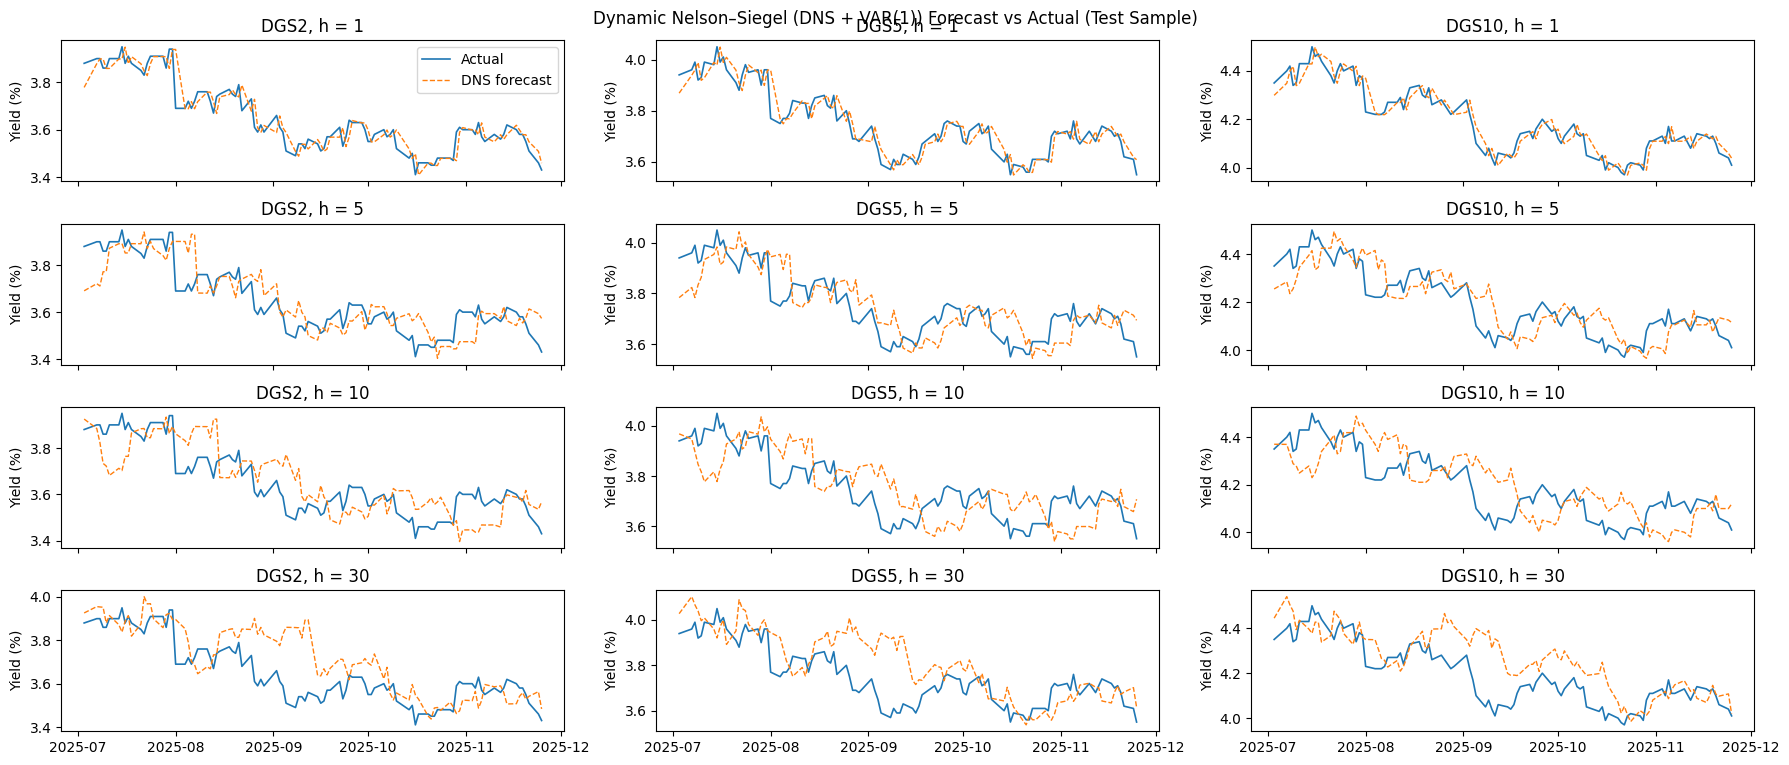

Saved DNS model to c:\Users\mango\Desktop\Bachelorarbeit\yield-curve-forecasting\models\DNS.pkl


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR


# Prepare settings, Fixed Lambda
maturity_cols = ["DGS2", "DGS5", "DGS10"]
tau_years = np.array([2.0, 5.0, 10.0])  
lmbda = 0.0609
horizons = [1, 5, 10, 30]


merged = merged.sort_index()
idx = merged.index
idx_array = np.array(idx)

# Quick sanity checks on dates
assert idx[0] <= train_start, "Train start before first data point"
assert idx[-1] >= test_end, "Test end after last data point in merged"

# ------------------- Extract DNS factors from yields -------------
def dns_loadings(tau, lam):
    tau = np.asarray(tau, dtype=float)
    one = np.ones_like(tau)
    term = (1 - np.exp(-lam * tau)) / (lam * tau)
    f1 = one
    f2 = term
    f3 = term - np.exp(-lam * tau)
    X = np.column_stack([f1, f2, f3])  # shape (n_maturities, 3)
    return X

# Cross-sectional loading matrix X (constant)
X = dns_loadings(tau_years, lmbda)  # shape (3, 3)

# DNS pseudo-inverse to map yields -> betas
XtX = X.T @ X
assert np.linalg.matrix_rank(XtX) == 3, "X'X is not full rank, DNS inversion fails"

B = np.linalg.inv(XtX) @ X.T  # shape (3, 3)

# Extract betas_t from yields_t (cross-sectional regression at each t)
y_mat = merged[maturity_cols].values  # shape (T, 3)
betas = (y_mat @ B.T)                 # shape (T, 3)

betas_df = pd.DataFrame(
    betas,
    index=merged.index,
    columns=["beta1", "beta2", "beta3"]
)

# Optional internal reconstruction sanity check (no forecasting yet)
y_recon = (betas @ X.T)  # T x 3
recon_rmse = np.sqrt(np.mean((y_mat - y_recon)**2))
print(f"[SANITY] DNS cross-sectional reconstruction RMSE (all sample, all maturities): {recon_rmse:.6f}")

# ------------------- Set up test positions -------------
test_mask = (idx_array >= test_start) & (idx_array <= test_end)
test_positions = np.where(test_mask)[0]
assert len(test_positions) > 0, "No test positions found between test_start and test_end"

last_test_pos = test_positions[-1]

# ------------------- Expanding-window VAR(1) forecasts for betas -------------
dns_pred = {(col, h): {} for col in maturity_cols for h in horizons}

# For safety logging
safety_log = {h: [] for h in horizons}

for h in horizons:
    print(f"\n=== Running DNS VAR(1) forecasts for horizon h = {h} ===")
    
    prev_train_size = 0
    prev_forecast_pos = None

    for pos in test_positions:
        origin_date = idx_array[pos]
        forecast_pos = pos + h

        # If we do not have y_{t+h} inside test window, skip
        if forecast_pos > last_test_pos:
            continue
        
        forecast_date = idx_array[forecast_pos]

       #------------------------- Construct expanding window -------------------------
        train_mask = (idx_array >= train_start) & (idx_array <= origin_date)
        train_betas = betas_df.loc[train_mask]
        train_size = len(train_betas)

        # Harsh safety checks on training window
        assert train_size > 0, "Empty training window, something is wrong"
        assert train_betas.index.min() >= train_start, "Training starts before train_start"
        assert train_betas.index.max() == origin_date, "Training does not end at origin date"
        assert all(train_betas.index <= origin_date), "Training contains observations after origin date (look ahead)"
        assert train_size >= prev_train_size, "Training window is not expanding monotonically"
        prev_train_size = train_size

        # Safety: forecast date must be strictly after origin date
        assert forecast_date > origin_date, "Forecast date is not strictly after origin date"

        # Safety: forecast date must be in test window
        assert (forecast_date >= test_start) and (forecast_date <= test_end), \
            f"Forecast date {forecast_date} outside test window"

        # Safety: monotonic forecast positions
        if prev_forecast_pos is not None:
            assert forecast_pos > prev_forecast_pos, "Forecast positions not strictly increasing"
        prev_forecast_pos = forecast_pos

        # ------------------------- Fit VAR(1) and forecast betas -------------------------
        var_model = VAR(train_betas)
        var_res = var_model.fit(maxlags=1)

        # Safety: we really fitted VAR(1)
        assert var_res.k_ar == 1, f"Expected VAR(1), got VAR({var_res.k_ar})"

        lag_order = var_res.k_ar
        beta_hist = train_betas.values[-lag_order:]  # last k_ar observations

        # h-step-ahead forecast path
        beta_forecast_path = var_res.forecast(beta_hist, steps=h)
        assert beta_forecast_path.shape == (h, 3), "Unexpected beta forecast shape"

        beta_forecast_h = beta_forecast_path[-1]  # horizon-h forecast

        # Map betas back into yields
        y_hat_vec = X @ beta_forecast_h  # length 3

        # Save predictions per maturity
        for j, col in enumerate(maturity_cols):
            dns_pred[(col, h)][forecast_date] = y_hat_vec[j]

        # Log first few entries for manual inspection
        if len(safety_log[h]) < 5:
            safety_log[h].append({
                "origin_date": pd.Timestamp(origin_date),
                "forecast_date": pd.Timestamp(forecast_date),
                "train_size": train_size
            })

# Show safety sample
print("\n=== Safety log (first 5 forecasts per horizon) ===")
for h in horizons:
    print(f"\nHorizon h = {h}:")
    if len(safety_log[h]) == 0:
        print("  (no entries logged)")
    else:
        for entry in safety_log[h]:
            print(
                f"  origin: {entry['origin_date'].date()}, "
                f"forecast: {entry['forecast_date'].date()}, "
                f"train_size: {entry['train_size']}"
            )

# -------------------------- Convert predictions to series and align with actuals -------------------------
dns_pred_series = {}
dns_actual_series = {}

for (col, h), pred_dict in dns_pred.items():
    if len(pred_dict) == 0:
        continue

    pred_s = pd.Series(pred_dict).sort_index()
    # Actual yields at the forecast dates
    actual_s = merged[col].loc[pred_s.index]

    # Safety: indices must match exactly
    assert pred_s.index.equals(actual_s.index), "Predictions and actuals indices do not match"
    # Safety: all dates inside test window
    assert all((pred_s.index >= test_start) & (pred_s.index <= test_end)), \
        "Prediction indices outside test window"

    # Safety: earliest prediction must not be before training start
    assert pred_s.index.min() > train_start, "Earliest prediction before training start"

    dns_pred_series[(col, h)] = pred_s
    dns_actual_series[(col, h)] = actual_s

# -------------------------- Evaluate DNS (VAR(1)) forecasts -------------------------
results = []

for (col, h), pred_s in dns_pred_series.items():
    actual_s = dns_actual_series[(col, h)]
    errors = actual_s - pred_s

    rmse = np.sqrt(np.mean(errors**2))
    mean_err = errors.mean()
    std_err = errors.std(ddof=1)

    results.append({
        "Maturity": col,
        "Horizon": h,
        "RMSE": rmse,
        "Mean_Error": mean_err,
        "Std_Error": std_err,
        "N_Forecasts": len(errors)
    })

dns_results_df = pd.DataFrame(results)
dns_results_df = dns_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("\nDNS (VAR(1)) performance (test period):")
display(dns_results_df)

# ------------------Create a visualization of the DNS (VAR(1)) forecast and the real yield ------------------
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 8),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]

        key = (col, h)
        if key not in dns_pred_series:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = dns_actual_series[key]
        pred_series   = dns_pred_series[key]

        # Optional: zoom into last N observations
        N = 100
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="DNS forecast", linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Dynamic Nelson–Siegel (DNS + VAR(1)) Forecast vs Actual (Test Sample)", y=0.95)
plt.tight_layout()
plt.show()


# ======================= SAVE DNS MODEL =======================

dns_bundle = {
    "predictions": dns_pred_series,    # dict[(maturity, h)] -> Series
    "actuals": dns_actual_series,      # same keys as predictions
    "metrics": dns_results_df          # RMSE etc.
}

with open(MODEL_DIR / "DNS.pkl", "wb") as f:
    pickle.dump(dns_bundle, f)

print(f"Saved DNS model to {MODEL_DIR / 'DNS.pkl'}")


Our results are as expected

-DNS underperforms RW over all maturities and horizons. RW is very hard to beat for so short lived periods

-But the difference is very small meaning the DNS model seems to captures important information

-DNS is just a "sophisticated" RW model 

# Build the Ridge Model

# Search best set of hyperparameters alpha and p

-We perform a grid search over alpha = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4] and p = [1, 3, 5, 10]

-Each model is trained from January 2009 to Janurary 2014 and then evaluated on 2014-2018. This way no model sees any of the OOS data (no lookahead bias)

-Each hyperparamter combination is evaluated on the in CV period 2014-2018 and the one with the lowest RMSE over the whole period is saved

-Features and struture are of course the same as below for training

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.linear_model import Ridge
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.base import clone

# # =====================================================
# # 0. Settings
# # =====================================================
# maturity_cols = ["DGS2", "DGS5", "DGS10"]
# horizons = [1, 5, 10, 30]

# train_start = pd.Timestamp("2009-01-02")
# train_end   = pd.Timestamp("2018-12-31")

# # Inner "CV validation" period (within training sample)
# cv_test_start = pd.Timestamp("2014-01-02")  # last ~5 years of train
# cv_test_end   = train_end

# min_train_size = 252  # at least ~1y of data to fit

# merged = merged.sort_index()
# idx = merged.index

# # =====================================================
# # 1. Hyperparameter grids
# # =====================================================
# alpha_grid = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
# p_grid     = [1, 3, 5, 10]   # lag length candidates

# print("Alpha grid:", alpha_grid)
# print("Lag grid (p):", p_grid)

# # =====================================================
# # 2. Helper: build lagged dataset for given target/horizon/p
# #     - Features: yields + spreads + curvature with lags
# #     - Target:   Δy_{t+h} = y_{t+h} - y_t  (yield change)
# # =====================================================
# def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
#     """
#     Features:
#         - Yields of all maturities with lags 0..max_lag
#         - Spreads and curvature (linear combos of yields) with lags 0..max_lag
#           * spread_5_2  = DGS5  - DGS2
#           * spread_10_2 = DGS10 - DGS2
#           * curv_5      = 2*DGS5 - DGS2 - DGS10

#     Target:
#         - Yield change Δy_{t+h} = y_{t+h} - y_t for target_col

#     Index:
#         - origin dates t (information set at time t)
#     """
#     # Base yields
#     base = merged[maturity_cols].copy()

#     # Spreads and curvature (no new info, just linear transformations)
#     base["spread_5_2"]  = base["DGS5"]  - base["DGS2"]
#     base["spread_10_2"] = base["DGS10"] - base["DGS2"]
#     base["curv_5"]      = 2 * base["DGS5"] - base["DGS2"] - base["DGS10"]

#     cols_for_lags = maturity_cols + ["spread_5_2", "spread_10_2", "curv_5"]

#     # Start empty df with same index
#     df = pd.DataFrame(index=merged.index)

#     # Add lagged features for all base cols
#     for col in cols_for_lags:
#         for lag in range(0, max_lag + 1):
#             df[f"{col}_lag{lag}"] = base[col].shift(lag)

#     # Target: yield change Δy_{t+h} = y_{t+h} - y_t
#     df["target_delta"] = merged[target_col].shift(-horizon) - merged[target_col]

#     # Drop rows with NaNs (from lags and shifting)
#     df = df.dropna()

#     # All columns except the target are features
#     feature_cols = [c for c in df.columns if c != "target_delta"]

#     X = df[feature_cols].values
#     y = df["target_delta"].values
#     dates = df.index  # origin dates t

#     return X, y, dates

# # =====================================================
# # 3. Helper: expanding-window Ridge for CV (NO look-ahead)
# #     - Trains on Δy targets
# #     - Reconstructs level forecasts: y_hat_{t+h|t} = y_t + Δy_hat
# #     - Returns series of LEVEL forecasts and LEVEL actuals
# # =====================================================
# def expanding_window_ridge_consistent(
#     X, y, dates, horizon,
#     train_start, test_start, test_end,
#     base_model, target_series,
#     min_train_size=252
# ):
#     """
#     Expanding-window Ridge used for CV, with NO look-ahead.

#     - Supervised rows (X, y) are indexed by origin date t in `dates`.
#     - Each row uses features at t and target Δy_{t+h} = y_{t+h} - y_t.
#     - At a forecast origin t0 in [test_start, test_end], we may only train on
#         rows with t <= t0 - h,
#       so that all targets y_{t+h} in the training set are in the past
#       relative to t0 (no look-ahead).
#     - For each origin t0, we:
#         * predict Δy_hat_{t+h}
#         * reconstruct level forecast: y_hat_{t+h|t0} = y_t0 + Δy_hat_{t+h}
#       and store it at index forecast_date = t0 + h.
#     - Returns:
#         pred_s   = series of LEVEL forecasts y_hat_{t+h|t}
#         actual_s = series of LEVEL actuals   y_{t+h}
#     """
#     dates = pd.DatetimeIndex(dates)

#     # Map dataset dates -> row index in X, y
#     ds_idx_map = {d: i for i, d in enumerate(dates)}

#     idx = merged.index
#     idx_array = np.array(idx)

#     # origin dates t0 in CV window
#     test_mask = (idx_array >= test_start) & (idx_array <= test_end)
#     test_positions = np.where(test_mask)[0]
#     if len(test_positions) == 0:
#         return None, None

#     last_pos = len(idx) - 1
#     last_test_pos = test_positions[-1]

#     pred_dict = {}
#     debug_count = 0  # limit debug prints

#     for pos in test_positions:
#         origin_date = idx[pos]  # t0

#         # need at least h days of history to define t0 - h
#         if pos - horizon < 0:
#             continue

#         # calendar date t0 - h (h index steps back)
#         train_end_date = idx[pos - horizon]

#         # origin date must be present in supervised dataset
#         if origin_date not in ds_idx_map:
#             continue

#         # forecast date t0 + h
#         forecast_pos = pos + horizon
#         if forecast_pos > last_test_pos or forecast_pos > last_pos:
#             continue
#         forecast_date = idx[forecast_pos]

#         # training rows: t in [train_start, t0 - h]
#         train_mask_ds = (dates >= train_start) & (dates <= train_end_date)
#         train_idx_ds = np.where(train_mask_ds)[0]

#         if len(train_idx_ds) < min_train_size:
#             continue

#         X_train, y_train = X[train_idx_ds], y[train_idx_ds]

#         origin_row = ds_idx_map[origin_date]
#         X_origin = X[origin_row:origin_row+1]

#         # DEBUG: print a few origins to verify no look-ahead
#         if debug_count < 5:
#             debug_count += 1
#             print(
#                 f"[DEBUG RIDGE CV] origin={origin_date.date()}, "
#                 f"train_end_date(t0-h)={train_end_date.date()}, "
#                 f"max_train_t={dates[train_idx_ds].max().date()}, "
#                 f"forecast_date(t0+h)={forecast_date.date()}"
#             )
#             # safety check: latest training t must be <= t0 - h
#             assert dates[train_idx_ds].max() <= train_end_date, \
#                 "DATA LEAK (Ridge CV): training uses dates after t0 - h!"

#         model = clone(base_model)
#         model.fit(X_train, y_train)
#         delta_hat = model.predict(X_origin)[0]   # predicted Δy_{t+h}

#         # reconstruct LEVEL forecast: y_hat_{t+h|t0} = y_t0 + Δy_hat_{t+h}
#         y_level_t0 = target_series.loc[origin_date]
#         y_hat_level = y_level_t0 + delta_hat

#         pred_dict[forecast_date] = y_hat_level

#     if len(pred_dict) == 0:
#         return None, None

#     pred_s = pd.Series(pred_dict).sort_index()
#     # Actual LEVEL yields at the forecast dates
#     actual_s = target_series.loc[pred_s.index]

#     return pred_s, actual_s

# # =====================================================
# # 4. Time-series CV over alpha and p (inside training period)
# # =====================================================
# cv_rows = []

# for target_col in maturity_cols:
#     # Full LEVEL series for this maturity (used to reconstruct y_hat and compare)
#     target_series_full = merged[target_col]

#     for h in horizons:
#         print(f"\n=== CV for Ridge (Δy target): target={target_col}, h={h} ===")

#         for p in p_grid:
#             X, y, dates = build_lagged_dataset(
#                 merged=merged,
#                 maturity_cols=maturity_cols,
#                 target_col=target_col,
#                 horizon=h,
#                 max_lag=p
#             )

#             # Restrict dataset to dates <= train_end (no peek into OOS)
#             mask_in_train = dates <= train_end
#             X_train_ds = X[mask_in_train]
#             y_train_ds = y[mask_in_train]
#             dates_train_ds = dates[mask_in_train]

#             if len(dates_train_ds) < min_train_size + 50:
#                 print(f"  Skipping p={p}: not enough data.")
#                 continue

#             for alpha in alpha_grid:
#                 ridge_pipeline = Pipeline([
#                     ("scaler", StandardScaler(with_mean=False)),
#                     ("ridge", Ridge(alpha=alpha))
#                 ])

#                 # Expanding-window CV within [cv_test_start .. cv_test_end]
#                 pred_s, actual_s = expanding_window_ridge_consistent(
#                     X=X_train_ds,
#                     y=y_train_ds,
#                     dates=dates_train_ds,
#                     horizon=h,
#                     train_start=train_start,
#                     test_start=cv_test_start,
#                     test_end=cv_test_end,
#                     base_model=ridge_pipeline,
#                     target_series=target_series_full,
#                     min_train_size=min_train_size
#                 )

#                 if pred_s is None:
#                     print(f"  (alpha={alpha}, p={p}) produced no forecasts.")
#                     continue

#                 # errors in LEVEL space: y_{t+h} - y_hat_{t+h|t}
#                 errors = actual_s - pred_s
#                 rmse = np.sqrt(np.mean(errors**2))

#                 cv_rows.append({
#                     "Maturity": target_col,
#                     "Horizon": h,
#                     "alpha": alpha,
#                     "p": p,
#                     "CV_RMSE": rmse,
#                     "N_Forecasts": len(errors)
#                 })

# ridge_cv_results = pd.DataFrame(cv_rows)
# ridge_cv_results = ridge_cv_results.set_index(["Maturity", "Horizon"]).sort_index()

# print("\nRidge CV results (Δy target, evaluated on levels; first rows):")
# display(ridge_cv_results.head())

# # =====================================================
# # 5. Choose best (alpha, p) per (Maturity, Horizon)
# # =====================================================
# ridge_best_params = {}

# for (mat, h), group in ridge_cv_results.groupby(level=[0, 1]):
#     best_row = group.sort_values("CV_RMSE").iloc[0]
#     ridge_best_params[(mat, h)] = {
#         "alpha": best_row["alpha"],
#         "p": int(best_row["p"]),
#         "CV_RMSE": best_row["CV_RMSE"],
#         "N_Forecasts": int(best_row["N_Forecasts"])
#     }

# print("\nBest Ridge hyperparameters per (Maturity, Horizon) [Δy target]:")
# for key, val in ridge_best_params.items():
#     mat, h = key
#     print(
#         f"  {mat}, h={h}: alpha={val['alpha']}, p={val['p']}, "
#         f"CV_RMSE={val['CV_RMSE']:.6f}, N={val['N_Forecasts']}"
#     )


Alpha grid: [0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
Lag grid (p): [1, 3, 5, 10]

=== CV for Ridge: target=DGS2, h=1 ===
[DEBUG RIDGE CV] origin=2014-01-02, train_end_date(t0-h)=2013-12-31, max_train_t=2013-12-31, forecast_date(t0+h)=2014-01-03
[DEBUG RIDGE CV] origin=2014-01-03, train_end_date(t0-h)=2014-01-02, max_train_t=2014-01-02, forecast_date(t0+h)=2014-01-06
[DEBUG RIDGE CV] origin=2014-01-06, train_end_date(t0-h)=2014-01-03, max_train_t=2014-01-03, forecast_date(t0+h)=2014-01-07
[DEBUG RIDGE CV] origin=2014-01-07, train_end_date(t0-h)=2014-01-06, max_train_t=2014-01-06, forecast_date(t0+h)=2014-01-08
[DEBUG RIDGE CV] origin=2014-01-08, train_end_date(t0-h)=2014-01-07, max_train_t=2014-01-07, forecast_date(t0+h)=2014-01-09
[DEBUG RIDGE CV] origin=2014-01-02, train_end_date(t0-h)=2013-12-31, max_train_t=2013-12-31, forecast_date(t0+h)=2014-01-03
[DEBUG RIDGE CV] origin=2014-01-03, train_end_date(t0-h)=2014-01-02, max_train_t=2014-01-02, forecast_date(t0+h)=2014-01-06
[DEBUG RIDGE CV] or

alpha  p   CV_RMSE  N_Forecasts
Maturity Horizon                                 
DGS10    1         0.05  1  0.042203         1249
         1         0.10  1  0.042208         1249
         1         0.15  1  0.042214         1249
         1         0.20  1  0.042221         1249
         1         0.30  1  0.042238         1249


Best Ridge hyperparameters per (Maturity, Horizon):
  DGS10, h=1: alpha=0.05, p=1, CV_RMSE=0.042203, N=1249
  DGS10, h=5: alpha=0.1, p=1, CV_RMSE=0.091810, N=1245
  DGS10, h=10: alpha=0.05, p=1, CV_RMSE=0.127730, N=1240
  DGS10, h=30: alpha=0.4, p=10, CV_RMSE=0.218936, N=1220
  DGS2, h=1: alpha=0.05, p=1, CV_RMSE=0.029417, N=1249
  DGS2, h=5: alpha=0.05, p=1, CV_RMSE=0.061222, N=1245
  DGS2, h=10: alpha=0.4, p=1, CV_RMSE=0.086094, N=1240
  DGS2, h=30: alpha=0.4, p=1, CV_RMSE=0.141045, N=1220
  DGS5, h=1: alpha=0.05, p=1, CV_RMSE=0.041442, N=1249
  DGS5, h=5: alpha=0.15, p=1, CV_RMSE=0.091203, N=1245
  DGS5, h=10: alpha=0.05, p=1, CV_RMSE=0.127605, N=1240
  DGS5, h=30: alpha=0.4, p=1, CV_RMSE=0.213164, N=1220


## Saving best paramters to save time

In [11]:
ridge_best_params = {
    ("DGS10", 1):  {"alpha": 0.05, "p": 1},
    ("DGS10", 5):  {"alpha": 0.10, "p": 1},
    ("DGS10", 10): {"alpha": 0.05, "p": 1},
    ("DGS10", 30): {"alpha": 0.40, "p": 10},

    ("DGS2", 1):   {"alpha": 0.05, "p": 1},
    ("DGS2", 5):   {"alpha": 0.05, "p": 1},
    ("DGS2", 10):  {"alpha": 0.40, "p": 1},
    ("DGS2", 30):  {"alpha": 0.40, "p": 1},

    ("DGS5", 1):   {"alpha": 0.05, "p": 1},
    ("DGS5", 5):   {"alpha": 0.15, "p": 1},
    ("DGS5", 10):  {"alpha": 0.05, "p": 1},
    ("DGS5", 30):  {"alpha": 0.40, "p": 1}
}


-We observe that for most horizons P=1. This makes sense because of the strong persistance of yields. The model collapses to an AR(1) process, which is close to the RW but a bit different.

-We also observe a high alpha for larger horizons, this makes sense because longer horizons typically incluide more noise which would explode coefficients if not regularized

# Train Ridge on best set of hyperparameters

-The model predicts yield changes and then reconstructs the level forecast

-As features we use all 3 maturity yields (DGS2, 5 and 10) as well as the y5-y2 spread, y10-y2 spread and the curvature (2*y5-y2-y10)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# =====================================================
# 0. Settings
# =====================================================
maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-25")

min_train_size = 252  # require at least ~1 year of data to fit

merged = merged.sort_index()
idx = merged.index
idx_array = np.array(idx)

# =====================================================
# 1. Supervised dataset builder (lags + horizon, Δy target)
# =====================================================
def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
    """
    Creates a supervised dataset for a given target maturity and horizon.

    Features (information set at time t):
        - Yields of all maturities with lags 0..max_lag
        - Spreads and curvature (linear combos of yields) with lags 0..max_lag
          * spread_5_2  = DGS5  - DGS2
          * spread_10_2 = DGS10 - DGS2
          * curv_5      = 2*DGS5 - DGS2 - DGS10

    Target:
        - Yield change Δy_{t+h} = y_{t+h} - y_t for target_col

    Index:
        - origin dates t (the date we observe the information set)
    """
    # Base yields
    base = merged[maturity_cols].copy()

    # Spreads and curvature (no new info, just linear combinations)
    base["spread_5_2"]  = base["DGS5"]  - base["DGS2"]
    base["spread_10_2"] = base["DGS10"] - base["DGS2"]
    base["curv_5"]      = 2 * base["DGS5"] - base["DGS2"] - base["DGS10"]

    cols_for_lags = maturity_cols + ["spread_5_2", "spread_10_2", "curv_5"]

    # Start empty df with same index
    df = pd.DataFrame(index=merged.index)

    # Add lagged features for all base cols
    for col in cols_for_lags:
        for lag in range(0, max_lag + 1):
            df[f"{col}_lag{lag}"] = base[col].shift(lag)

    # Target: yield change Δy_{t+h} = y_{t+h} - y_t
    df["target_delta"] = merged[target_col].shift(-horizon) - merged[target_col]

    # Drop rows with NaNs (from lags and shifting)
    df = df.dropna()

    # All columns except the target are features
    feature_cols = [c for c in df.columns if c != "target_delta"]

    X = df[feature_cols].values
    y = df["target_delta"].values
    dates = df.index  # origin dates t

    return X, y, dates

# =====================================================
# 2. Expanding window forecasting function (Δy target, returns LEVEL forecasts)
# =====================================================
def expanding_window_ridge(
    X, y, dates, horizon,
    train_start, test_start, test_end,
    base_model, target_series,
    min_train_size=252
):
    """
    Expanding-window Ridge with NO look-ahead, using Δy targets.

    Supervised rows (X, y) are indexed by origin date t in `dates`.
    Each row uses features at t and target
        Δy_{t+h} = y_{t+h} - y_t
    (because of shift(-horizon) in the dataset builder).

    At a forecast origin t0 (calendar date), we may only train on rows
    with t <= t0 - h, so that all targets y_{t+h} in the training set
    are in the past relative to t0.

    For each origin t0 in [test_start, test_end]:
        - predict Δy_hat_{t0+h|t0}
        - reconstruct level forecast:
            y_hat_{t0+h|t0} = y_t0 + Δy_hat_{t0+h|t0}
        - store this forecast at index forecast_date = t0 + h.

    Returns:
        pred_s   : series of LEVEL forecasts y_hat_{t+h|t}
        actual_s : series of LEVEL actuals   y_{t+h}
    """
    dates = pd.DatetimeIndex(dates)

    # Map origin dates in supervised dataset -> row indices
    ds_idx_map = {d: i for i, d in enumerate(dates)}

    idx = merged.index
    idx_array = np.array(idx)

    # Origin dates t0 in the test window
    test_mask = (idx_array >= test_start) & (idx_array <= test_end)
    test_positions = np.where(test_mask)[0]
    if len(test_positions) == 0:
        return None, None

    last_pos = len(idx) - 1
    last_test_pos = test_positions[-1]

    pred_dict = {}
    debug_count = 0  # limit debug prints

    for pos in test_positions:
        origin_date = idx[pos]  # t0

        # Need at least 'horizon' days of history to define t0 - h
        if pos - horizon < 0:
            continue

        # Calendar date t0 - h (h index steps back)
        train_end_date = idx[pos - horizon]

        # origin date must be present in supervised dataset
        if origin_date not in ds_idx_map:
            continue

        # Forecast date t0 + h
        forecast_pos = pos + horizon
        if forecast_pos > last_test_pos or forecast_pos > last_pos:
            # drop last h-1 origins so that t0 + h stays in test window
            continue

        forecast_date = idx[forecast_pos]

        # Training rows: t in [train_start, t0 - h]
        train_mask_ds = (dates >= train_start) & (dates <= train_end_date)
        train_idx_ds = np.where(train_mask_ds)[0]

        if len(train_idx_ds) < min_train_size:
            continue

        X_train, y_train = X[train_idx_ds], y[train_idx_ds]

        origin_row = ds_idx_map[origin_date]
        X_origin = X[origin_row:origin_row+1]

        # DEBUG: print a few origins to verify no look-ahead
        if debug_count < 5:
            debug_count += 1
            print(
                f"[DEBUG RIDGE Δy] origin={origin_date.date()}, "
                f"train_end_date(t0-h)={train_end_date.date()}, "
                f"max_train_t={dates[train_idx_ds].max().date()}, "
                f"forecast_date(t0+h)={forecast_date.date()}"
            )
            # safety check: latest training t must be <= t0 - h
            assert dates[train_idx_ds].max() <= train_end_date, \
                "DATA LEAK (Ridge Δy): training uses dates after t0 - h!"

        model = clone(base_model)
        model.fit(X_train, y_train)
        delta_hat = model.predict(X_origin)[0]   # predicted Δy_{t+h}

        # reconstruct LEVEL forecast: y_hat_{t+h|t0} = y_t0 + Δy_hat_{t+h}
        y_level_t0 = target_series.loc[origin_date]
        y_hat_level = y_level_t0 + delta_hat

        pred_dict[forecast_date] = y_hat_level

    if len(pred_dict) == 0:
        return None, None

    pred_s = pd.Series(pred_dict).sort_index()
    # Actual LEVEL yields at the forecast dates
    actual_s = target_series.loc[pred_s.index]

    return pred_s, actual_s

# =====================================================
# 3. Final Ridge evaluation with tuned hyperparameters
#    (ridge_best_params must exist from the CV cell)
# =====================================================

ridge_pred_series = {}
ridge_actual_series = {}
results = []

for target_col in maturity_cols:
    # Full LEVEL series for this maturity (used to reconstruct y_hat and compare)
    target_series_full = merged[target_col]

    for h in horizons:
        # fetch best alpha and p from CV step
        best = ridge_best_params.get((target_col, h), None)
        if best is None:
            print(f"No best params found for {target_col}, h={h}, skipping.")
            continue

        alpha   = best["alpha"]
        max_lag = best["p"]

        print(f"Running Ridge forecasts for {target_col}, h = {h}, "
              f"alpha={alpha}, p={max_lag} ...")

        # Build supervised dataset with the chosen lag length p (Δy target)
        X, y, dates = build_lagged_dataset(
            merged=merged,
            maturity_cols=maturity_cols,
            target_col=target_col,
            horizon=h,
            max_lag=max_lag
        )

        # Define Ridge pipeline with the chosen alpha
        ridge_pipeline = Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("ridge", Ridge(alpha=alpha))
        ])

        # Run expanding-window Ridge forecasting (Δy → LEVEL)
        pred_s, actual_s = expanding_window_ridge(
            X=X,
            y=y,
            dates=dates,
            horizon=h,
            train_start=train_start,
            test_start=test_start,
            test_end=test_end,
            base_model=ridge_pipeline,
            target_series=target_series_full,
            min_train_size=min_train_size
        )

        if pred_s is None:
            print(f"  -> No forecasts produced for {target_col}, h={h}")
            continue

        # Align and compute errors in LEVEL space
        errors = actual_s - pred_s

        rmse = np.sqrt(np.mean(errors**2))
        mean_err = errors.mean()
        std_err = errors.std(ddof=1)

        results.append({
            "Maturity": target_col,
            "Horizon": h,
            "RMSE": rmse,
            "Mean_Error": mean_err,
            "Std_Error": std_err,
            "N_Forecasts": len(errors),
            "alpha": alpha,
            "p": max_lag
        })

        ridge_pred_series[(target_col, h)] = pred_s
        ridge_actual_series[(target_col, h)] = actual_s

# =====================================================
# 4. Results table
# =====================================================
ridge_results_df = pd.DataFrame(results)
ridge_results_df = ridge_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("\nRidge (expanding window, tuned hyperparameters, Δy target, evaluated on levels) performance (test period):")
display(ridge_results_df)

# =====================================================
# 5. Visualization: actual vs Ridge forecast (last part of test sample)
# =====================================================
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 10),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]
        key = (col, h)

        if key not in ridge_pred_series:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = ridge_actual_series[key]
        pred_series   = ridge_pred_series[key]

        # Optional: zoom into last N observations
        N = len(actual_series)  # or e.g. 500
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="Ridge forecast", linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Ridge Regression Forecast vs Actual (Test Sample, tuned hyperparameters, Δy target)", y=0.95)
plt.tight_layout()
plt.show()

# ======================= SAVE RIDGE MODEL =======================

ridge_bundle = {
    "predictions": ridge_pred_series,   # dict[(maturity, horizon)] -> Series
    "actuals": ridge_actual_series,     # aligned actual yield series
    "metrics": ridge_results_df,        # forecast RMSE, errors, hyperparams
    "hyperparameters": ridge_best_params  # optional but valuable for reproducibility
}

model_path = MODEL_DIR / "Ridge.pkl"

with open(model_path, "wb") as f:
    pickle.dump(ridge_bundle, f)

print(f"✔ Saved Ridge model to {model_path}")



NameError: name 'ridge_best_params' is not defined

# XGBoost Implementation

# Find best set up Hyperparameter 

-We perform a similar grid search as for ridge over the grid: p_grid= [5, 60, 120], eta_grid = [0.05, 0.1], max_depth_grid= [2, 3], n_estimators_grid = [200]

-We use CV_Step = 10, to only make a forecast every 10 CV days to reduce compuations by factor 10. Again this is for computational efficiency reasons

-The grid could be much bigger but my PC already took several hours for this grid due to the large loop nature of the problem (reestimate the model at every time step)

-Besides that the XGBoost model has the same setup as Ridge consider features, periods and evaluation

In [ ]:
# import numpy as np
# import pandas as pd
# from xgboost import XGBRegressor

# # =====================================================
# # 0. Settings
# # =====================================================
# maturity_cols = ["DGS2", "DGS5", "DGS10"]
# horizons = [1, 5, 10, 30]

# train_start = pd.Timestamp("2009-01-02")
# train_end   = pd.Timestamp("2018-12-31")

# # Inner CV validation window (inside training sample, like Ridge)
# cv_test_start = pd.Timestamp("2014-01-02")
# cv_test_end   = train_end

# min_train_size = 252  # at least ~1 year of data

# merged = merged.sort_index()

# # ----- GPU / CPU toggle -----
# USE_GPU = False  # your current xgboost build has no gpu_hist
# if USE_GPU:
#     tree_method = "gpu_hist"
# else:
#     tree_method = "hist"

# # Use only every CV_STEP-th day as CV origin
# CV_STEP = 10     # set to 5 or 10 depending on speed

# # =====================================================
# # 1. Helper: build lagged dataset for given target/horizon/p
# #    - Features: yields + spreads + curvature with lags
# #    - Target:   Δy_{t+h} = y_{t+h} - y_t  (yield change)
# # =====================================================
# def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
#     """
#     For each date t (origin):
#       Features (information set at time t):
#         - Yields of all maturities with lags 0..max_lag
#         - Spreads and curvature with lags 0..max_lag
#           * spread_5_2  = DGS5  - DGS2
#           * spread_10_2 = DGS10 - DGS2
#           * curv_5      = 2*DGS5 - DGS2 - DGS10

#       Target:
#         - Yield change Δy_{t+h} = y_{t+h} - y_t for target_col

#       Index:
#         - origin dates t
#     """
#     # Base yields
#     base = merged[maturity_cols].copy()

#     # Spreads and curvature (linear combinations)
#     base["spread_5_2"]  = base["DGS5"]  - base["DGS2"]
#     base["spread_10_2"] = base["DGS10"] - base["DGS2"]
#     base["curv_5"]      = 2 * base["DGS5"] - base["DGS2"] - base["DGS10"]

#     cols_for_lags = maturity_cols + ["spread_5_2", "spread_10_2", "curv_5"]

#     # Start empty df with same index
#     df = pd.DataFrame(index=merged.index)

#     # Add lagged features for all base columns
#     for col in cols_for_lags:
#         for lag in range(0, max_lag + 1):
#             df[f"{col}_lag{lag}"] = base[col].shift(lag)

#     # Target: yield change Δy_{t+h} = y_{t+h} - y_t
#     df["target_delta"] = merged[target_col].shift(-horizon) - merged[target_col]

#     # Drop rows with NaNs (from lags and shifting)
#     df = df.dropna()

#     # Features = all columns except target
#     feature_cols = [c for c in df.columns if c != "target_delta"]
#     X = df[feature_cols].values
#     y = df["target_delta"].values
#     dates = df.index  # origin dates t

#     return X, y, dates

# # =====================================================
# # 2. Helper: expanding-window forecasting for CV (NO LOOK-AHEAD)
# #    - trains on Δy
# #    - reconstructs LEVEL forecasts y_hat_{t+h|t0} = y_t0 + Δy_hat
# # =====================================================
# def expanding_window_xgb_consistent(
#     X, y, dates, horizon,
#     train_start, test_start, test_end,
#     base_model, target_series,
#     min_train_size=252,
#     cv_step=10,
# ):
#     """
#     Expanding-window XGBoost CV with NO look-ahead, using Δy targets.

#     - Supervised rows are indexed by origin date t (dates).
#     - Each row uses features at t and target Δy_{t+h} = y_{t+h} - y_t.
#     - At a forecast origin t0, we may only train on rows with t <= t0 - h,
#       so that all targets in the training set are in the past relative to t0.
#     - Model predicts Δy_hat; we reconstruct LEVEL forecast as:
#         y_hat_{t0+h|t0} = y_t0 + Δy_hat
#       and evaluate RMSE in LEVEL space against y_{t0+h}.
#     - Origins used for CV: every 'cv_step'-th trading day between test_start and test_end.
#     """

#     dates = pd.DatetimeIndex(dates)

#     # Map supervised dataset dates -> row index in X, y
#     ds_idx_map = {d: i for i, d in enumerate(dates)}

#     idx = merged.index
#     idx_array = np.array(idx)

#     # All possible origin positions in calendar time
#     test_mask = (idx_array >= test_start) & (idx_array <= test_end)
#     all_positions = np.where(test_mask)[0]

#     # Subsample origins: e.g. every 5th or 10th day
#     test_positions = all_positions[::cv_step]

#     if len(test_positions) == 0:
#         return None, None

#     last_test_pos = test_positions[-1]
#     last_pos = len(idx) - 1

#     pred_dict = {}
#     debug_prints = 0  # to limit debug output

#     for pos in test_positions:
#         origin_date = idx[pos]  # calendar origin t0

#         # Need at least 'horizon' days of history to define t0 - h
#         if pos - horizon < 0:
#             continue

#         # Calendar date corresponding to t0 - h (h index steps back)
#         train_end_date = idx[pos - horizon]

#         # origin date must exist in the supervised dataset (dates index)
#         if origin_date not in ds_idx_map:
#             continue

#         # Expanding training window in dataset time:
#         #   use rows with t in [train_start, train_end_date]  (<= t0 - h)
#         train_mask_ds = (dates >= train_start) & (dates <= train_end_date)
#         train_idx_ds = np.where(train_mask_ds)[0]

#         if len(train_idx_ds) < min_train_size:
#             continue

#         # Forecast date = t0 + h (ensure it's still inside CV window)
#         forecast_pos = pos + horizon
#         if forecast_pos > last_test_pos or forecast_pos > last_pos:
#             # drop last h-1 origins so that t0 + h stays within cv_test_end
#             continue

#         forecast_date = idx[forecast_pos]

#         X_train, y_train = X[train_idx_ds], y[train_idx_ds]

#         origin_row = ds_idx_map[origin_date]
#         X_origin = X[origin_row:origin_row+1]

#         # DEBUG: print a few cases to check dates (no look-ahead)
#         if debug_prints < 5:
#             debug_prints += 1
#             print("\n[DEBUG XGB Δy] CV origin:", origin_date.date(),
#                   "| train_end_date (t0 - h):", train_end_date.date(),
#                   "| max_train_t:", dates[train_idx_ds].max().date(),
#                   "| forecast_date (t0 + h):", forecast_date.date())
#             # Sanity check: training must end at or before t0 - h
#             assert dates[train_idx_ds].max() <= train_end_date, \
#                 "Data leak: training uses dates after t0 - h!"

#         # Fit a fresh model on the expanding window
#         model = XGBRegressor(**base_model.get_params())
#         model.fit(X_train, y_train)

#         # Predict Δy_hat for origin t0
#         delta_hat = model.predict(X_origin)[0]

#         # Reconstruct LEVEL forecast: y_hat_{t0+h|t0} = y_t0 + Δy_hat
#         y_level_t0 = target_series.loc[origin_date]
#         y_hat_level = y_level_t0 + delta_hat

#         pred_dict[forecast_date] = y_hat_level

#     if len(pred_dict) == 0:
#         return None, None

#     pred_s = pd.Series(pred_dict).sort_index()
#     # Actual LEVEL yields at the forecast dates
#     actual_s = target_series.loc[pred_s.index]

#     return pred_s, actual_s

# # =====================================================
# # 3. Hyperparameter grid
# # =====================================================
# p_grid            = [5, 60, 120]   # lag length candidates
# eta_grid          = [0.05, 0.1]    # learning rate
# max_depth_grid    = [2, 3]         # tree depth
# n_estimators_grid = [200]          # number of trees

# # =====================================================
# # 4. Time-series CV over XGBoost hyperparameters (with subsampled origins)
# # =====================================================
# cv_rows = []

# for target_col in maturity_cols:
#     target_series_full = merged[target_col]  # LEVEL series (for reconstruction & evaluation)

#     for h in horizons:
#         print(f"\n=== XGBoost CV (Δy target, eval on levels): target={target_col}, h={h} ===")

#         for p in p_grid:
#             # Build supervised dataset for this lag length (Δy target)
#             X, y, dates = build_lagged_dataset(
#                 merged=merged,
#                 maturity_cols=maturity_cols,
#                 target_col=target_col,
#                 horizon=h,
#                 max_lag=p
#             )

#             # Restrict dataset to training sample only (no future info)
#             mask_in_train = dates <= train_end
#             X_train_ds = X[mask_in_train]
#             y_train_ds = y[mask_in_train]
#             dates_train_ds = dates[mask_in_train]

#             if len(dates_train_ds) < min_train_size + 50:
#                 print(f"  Skipping p={p}: not enough data.")
#                 continue

#             for eta in eta_grid:
#                 for max_depth in max_depth_grid:
#                     for n_estimators in n_estimators_grid:
#                         print(
#                             f"  p={p}, eta={eta}, depth={max_depth}, "
#                             f"n_estimators={n_estimators}"
#                         )

#                         xgb_model = XGBRegressor(
#                             objective="reg:squarederror",
#                             learning_rate=eta,
#                             max_depth=max_depth,
#                             n_estimators=n_estimators,
#                             subsample=0.7,
#                             colsample_bytree=0.7,
#                             min_child_weight=1,
#                             reg_lambda=1.0,
#                             random_state=42,
#                             n_jobs=-1,
#                             tree_method=tree_method,
#                         )

#                         # Expanding-window CV within [cv_test_start, cv_test_end]
#                         pred_s, actual_s = expanding_window_xgb_consistent(
#                             X=X_train_ds,
#                             y=y_train_ds,
#                             dates=dates_train_ds,
#                             horizon=h,
#                             train_start=train_start,
#                             test_start=cv_test_start,
#                             test_end=cv_test_end,
#                             base_model=xgb_model,
#                             target_series=target_series_full,
#                             min_train_size=min_train_size,
#                             cv_step=CV_STEP,  # use every CV_STEP-th origin
#                         )

#                         if pred_s is None:
#                             print("    -> produced no forecasts, skipping.")
#                             continue

#                         # Errors in LEVEL space: y_{t+h} - y_hat_{t+h|t}
#                         errors = actual_s - pred_s
#                         rmse = np.sqrt(np.mean(errors**2))

#                         cv_rows.append({
#                             "Maturity": target_col,
#                             "Horizon": h,
#                             "p": p,
#                             "eta": eta,
#                             "max_depth": max_depth,
#                             "n_estimators": n_estimators,
#                             "CV_RMSE": rmse,
#                             "N_Forecasts": len(errors),
#                         })

# # =====================================================
# # 5. Collect CV results and select best params
# # =====================================================
# xgb_cv_results = pd.DataFrame(cv_rows)
# if not xgb_cv_results.empty:
#     xgb_cv_results = xgb_cv_results.set_index(["Maturity", "Horizon"]).sort_index()

# print("\nXGBoost CV results (Δy target, eval on levels, first rows):")
# display(xgb_cv_results.head())

# xgb_best_params = {}

# if not xgb_cv_results.empty:
#     for (mat, h), group in xgb_cv_results.groupby(level=[0, 1]):
#         best_row = group.sort_values("CV_RMSE").iloc[0]
#         xgb_best_params[(mat, h)] = {
#             "p": int(best_row["p"]),
#             "eta": float(best_row["eta"]),
#             "max_depth": int(best_row["max_depth"]),
#             "n_estimators": int(best_row["n_estimators"]),
#             "CV_RMSE": float(best_row["CV_RMSE"]),
#             "N_Forecasts": int(best_row["N_Forecasts"]),
#         }

# print("\nBest XGBoost hyperparameters per (Maturity, Horizon) [Δy target]:")
# for key, val in xgb_best_params.items():
#     mat, h = key
#     print(
#         f"  {mat}, h={h}: "
#         f"p={val['p']}, eta={val['eta']}, depth={val['max_depth']}, "
#         f"n_estimators={val['n_estimators']}, "
#         f"CV_RMSE={val['CV_RMSE']:.6f}, N={val['N_Forecasts']}"
#     )



=== XGBoost CV (Δy target, eval on levels): target=DGS2, h=1 ===
  p=5, eta=0.05, depth=2, n_estimators=200

[DEBUG XGB Δy] CV origin: 2014-01-02 | train_end_date (t0 - h): 2013-12-31 | max_train_t: 2013-12-31 | forecast_date (t0 + h): 2014-01-03

[DEBUG XGB Δy] CV origin: 2014-01-16 | train_end_date (t0 - h): 2014-01-15 | max_train_t: 2014-01-15 | forecast_date (t0 + h): 2014-01-17

[DEBUG XGB Δy] CV origin: 2014-01-31 | train_end_date (t0 - h): 2014-01-30 | max_train_t: 2014-01-30 | forecast_date (t0 + h): 2014-02-03

[DEBUG XGB Δy] CV origin: 2014-02-14 | train_end_date (t0 - h): 2014-02-13 | max_train_t: 2014-02-13 | forecast_date (t0 + h): 2014-02-18

[DEBUG XGB Δy] CV origin: 2014-03-03 | train_end_date (t0 - h): 2014-02-28 | max_train_t: 2014-02-28 | forecast_date (t0 + h): 2014-03-04
  p=5, eta=0.05, depth=3, n_estimators=200

[DEBUG XGB Δy] CV origin: 2014-01-02 | train_end_date (t0 - h): 2013-12-31 | max_train_t: 2013-12-31 | forecast_date (t0 + h): 2014-01-03

[DEBUG XGB Δy

p   eta  max_depth  n_estimators   CV_RMSE  N_Forecasts
Maturity Horizon                                                          
DGS10    1         5  0.05          2           200  0.050246          124
         1         5  0.05          3           200  0.049630          124
         1         5  0.10          2           200  0.049917          124
         1         5  0.10          3           200  0.051162          124
         1        60  0.05          2           200  0.050427          124


Best XGBoost hyperparameters per (Maturity, Horizon) [Δy target]:
  DGS10, h=1: p=5, eta=0.05, depth=3, n_estimators=200, CV_RMSE=0.049630, N=124
  DGS10, h=5: p=5, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.102125, N=124
  DGS10, h=10: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.141802, N=124
  DGS10, h=30: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.233550, N=122
  DGS2, h=1: p=5, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.035172, N=124
  DGS2, h=5: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.064401, N=124
  DGS2, h=10: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.086891, N=124
  DGS2, h=30: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.145397, N=122
  DGS5, h=1: p=5, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.047965, N=124
  DGS5, h=5: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.098882, N=124
  DGS5, h=10: p=120, eta=0.05, depth=2, n_estimators=200, CV_RMSE=0.135445, N=124
  DGS5, h=30: p=120, eta=0.05, depth=3, n

# Save best set of hyperparameters here

In [ ]:
# ============================================
# Hard-coded XGB hyperparameters (from CV results)
# ============================================

xgb_best_params = {

    # --------- DGS10 ----------
    ("DGS10", 1):  {"p": 5, "eta": 0.05, "max_depth": 3, "n_estimators": 200},
    ("DGS10", 5):  {"p": 5, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS10", 10): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS10", 30): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},

    # --------- DGS2  ----------
    ("DGS2", 1):  {"p": 5, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS2", 5):  {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS2", 10): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS2", 30): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},

    # --------- DGS5 ----------
    ("DGS5", 1):  {"p": 5,  "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS5", 5):  {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS5", 10): {"p": 120, "eta": 0.05, "max_depth": 2, "n_estimators": 200},
    ("DGS5", 30): {"p": 120, "eta": 0.05, "max_depth": 3, "n_estimators": 200},
}


-For short horizons the lag length is very low p=5, because recent information is the most important (We've seen this before for Ridge aswell)

-For longer periods p jumps to 120 indicating the model benefits from more data

-Learning rate is always low at 0.05 indicating slow learning which avoids overfitting and leads to more stable predictions

# Train the final model on the best set up Hyperparameters and save it


Running XGBoost forecasts for DGS2, h=1 (Δy target; p=5, eta=0.05, depth=2, trees=200) ...
[DEBUG TEST XGB Δy] origin=2019-01-02, train_end_date(t0-h)=2018-12-31, max_train_t=2018-12-31, forecast_date(t0+h)=2019-01-03
[DEBUG TEST XGB Δy] origin=2019-01-03, train_end_date(t0-h)=2019-01-02, max_train_t=2019-01-02, forecast_date(t0+h)=2019-01-04
[DEBUG TEST XGB Δy] origin=2019-01-04, train_end_date(t0-h)=2019-01-03, max_train_t=2019-01-03, forecast_date(t0+h)=2019-01-07
[DEBUG TEST XGB Δy] origin=2019-01-07, train_end_date(t0-h)=2019-01-04, max_train_t=2019-01-04, forecast_date(t0+h)=2019-01-08
[DEBUG TEST XGB Δy] origin=2019-01-08, train_end_date(t0-h)=2019-01-07, max_train_t=2019-01-07, forecast_date(t0+h)=2019-01-09

Running XGBoost forecasts for DGS2, h=5 (Δy target; p=120, eta=0.05, depth=2, trees=200) ...
[DEBUG TEST XGB Δy] origin=2019-01-02, train_end_date(t0-h)=2018-12-24, max_train_t=2018-12-24, forecast_date(t0+h)=2019-01-09
[DEBUG TEST XGB Δy] origin=2019-01-03, train_end_dat

RMSE  Mean_Error  Std_Error  N_Forecasts    p    eta  \
Maturity Horizon                                                             
DGS10    1        0.061816    0.001163   0.061824         1712    5  0.050   
         5        0.136784    0.006675   0.136661         1708    5  0.050   
         10       0.193798    0.016023   0.193191         1703  120  0.050   
         30       0.388307    0.020634   0.387874         1683  120  0.050   
DGS2     1        0.065850    0.003014   0.065800         1712    5  0.050   
         5        0.144119    0.018338   0.142989         1708  120  0.050   
         10       0.210959    0.024934   0.209541         1703  120  0.050   
         30       0.413400    0.059899   0.409159         1683  120  0.050   
DGS5     1        0.065312    0.001975   0.065301         1712    5  0.051   
         5        0.141190    0.010634   0.140830         1708  120  0.050   
         10       0.206624    0.021093   0.205605         1703  120  0.050   
         30       0.414612    0.031400   0.413545         1683  120  0.050   

                  max_depth  n_estimators  
Maturity Horizon                           
DGS10    1                3           200  
         5                2           200  
         10               2           200  
         30               2           200  
DGS2     1                2           200  
         5                2           200  
         10               2           200  
         30               2           200  
DGS5     1                2           200  
         5                2           200  
         10               2           200  
         30               3           200

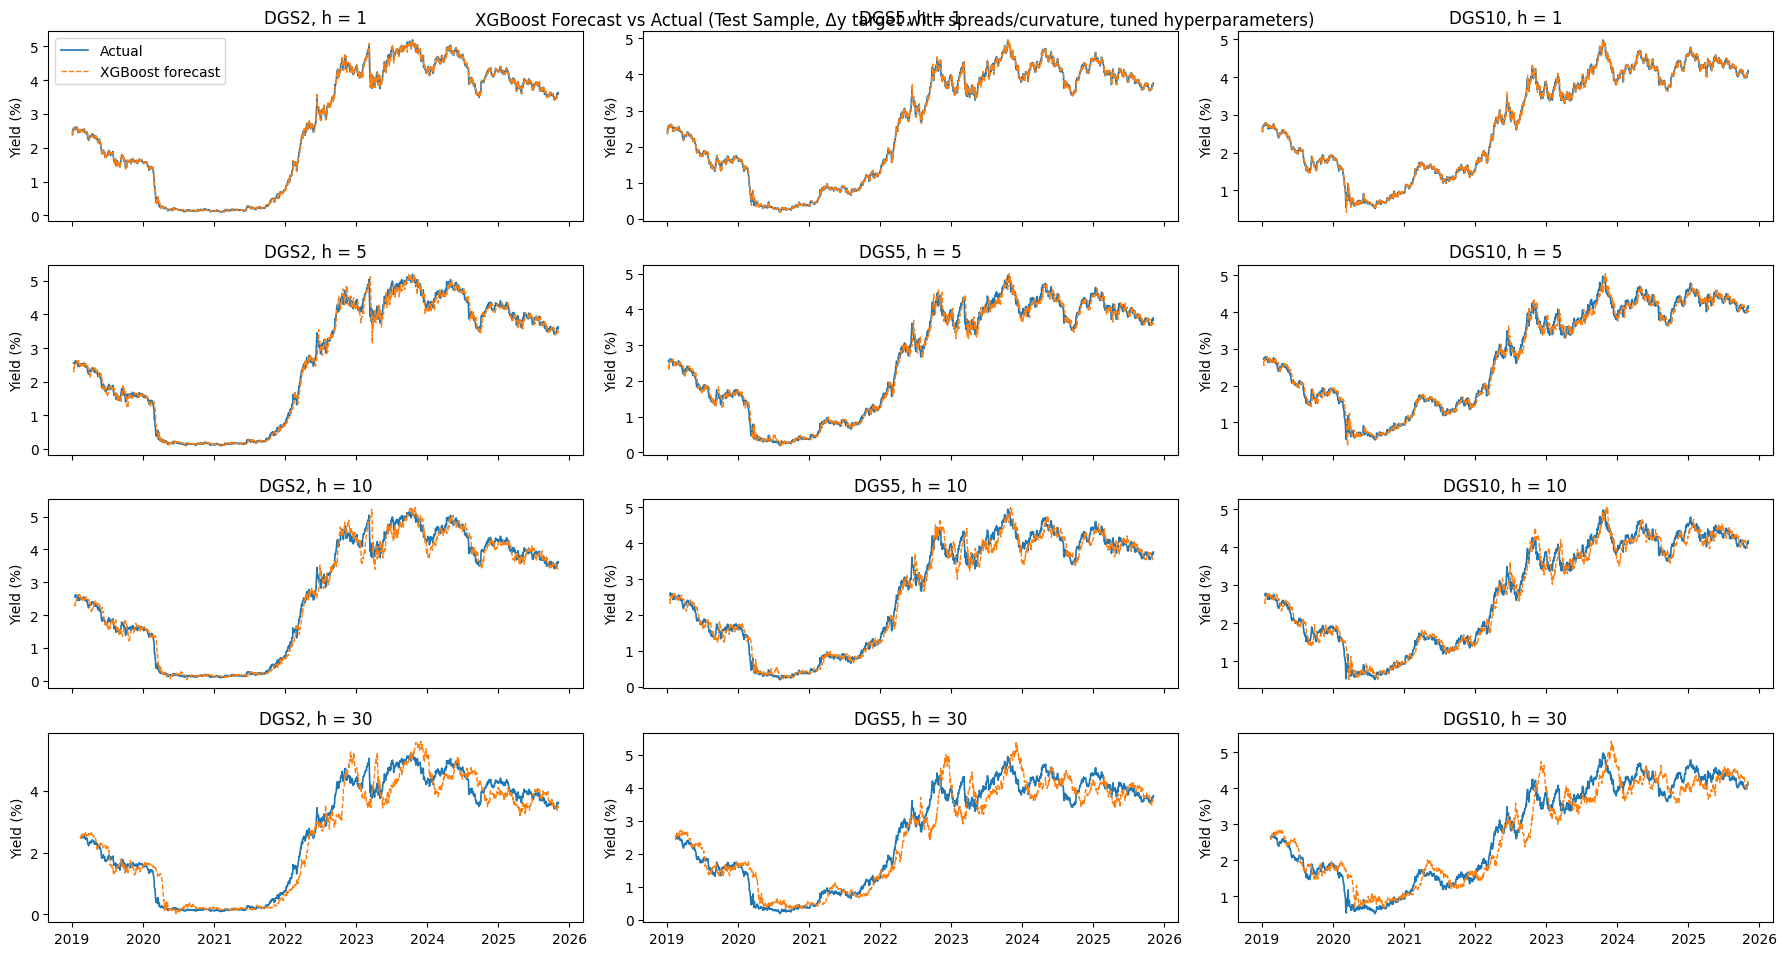

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# =====================================================
# 0. Settings
# =====================================================
maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-25")

min_train_size = 252  # at least ~1 year of data

merged = merged.sort_index()
idx = merged.index

# =====================================================
# 1. GPU / CPU toggle
# =====================================================
USE_GPU = False  # set False on MacBook, True on RTX desktop with gpu_hist support

if USE_GPU:
    tree_method = "gpu_hist"   # GPU-accelerated hist algorithm
else:
    tree_method = "hist"       # CPU version

# =====================================================
# 2. Helper: build lagged dataset (Δy target + spreads/curvature)
# =====================================================
def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
    """
    For each date t (origin):
      Features (information set at time t):
        - Yields of all maturities with lags 0..max_lag
        - Spreads and curvature with lags 0..max_lag
          * spread_5_2  = DGS5  - DGS2
          * spread_10_2 = DGS10 - DGS2
          * curv_5      = 2*DGS5 - DGS2 - DGS10

      Target:
        - Yield change Δy_{t+h} = y_{t+h} - y_t for target_col

      Index:
        - origin dates t
    """
    # Base yields
    base = merged[maturity_cols].copy()

    # Spreads & curvature
    base["spread_5_2"]  = base["DGS5"]  - base["DGS2"]
    base["spread_10_2"] = base["DGS10"] - base["DGS2"]
    base["curv_5"]      = 2 * base["DGS5"] - base["DGS2"] - base["DGS10"]

    cols_for_lags = maturity_cols + ["spread_5_2", "spread_10_2", "curv_5"]

    df = pd.DataFrame(index=merged.index)

    # Lagged features
    for col in cols_for_lags:
        for lag in range(0, max_lag + 1):
            df[f"{col}_lag{lag}"] = base[col].shift(lag)

    # Target: Δy_{t+h} = y_{t+h} - y_t
    df["target_delta"] = merged[target_col].shift(-horizon) - merged[target_col]

    df = df.dropna()

    feature_cols = [c for c in df.columns if c != "target_delta"]
    X = df[feature_cols].values
    y = df["target_delta"].values
    dates = df.index  # origin dates t

    return X, y, dates

# =====================================================
# 3. Helper: expanding-window XGBoost (strict, no look-ahead, Δy -> LEVEL)
# =====================================================
def expanding_window_xgb(
    X, y, dates, horizon,
    train_start, test_start, test_end,
    base_params, target_series,
    min_train_size=252
):
    """
    Expanding-window forecasting with NO look-ahead, using Δy targets.

    - Supervised rows (X, y) are indexed by origin date t (in 'dates').
    - Each row uses features at t and target Δy_{t+h} = y_{t+h} - y_t.
    - At a forecast origin t0 (calendar date), we may only train on rows
        with t <= t0 - h,
      so that all targets y_{t+h} in the training set are in the past
      relative to t0.
    - Model predicts Δy_hat; we reconstruct LEVEL forecast as:
        y_hat_{t0+h|t0} = y_t0 + Δy_hat
      and only keep forecasts where forecast_date in [test_start, test_end].
    """

    dates = pd.DatetimeIndex(dates)

    # Map dataset dates -> row index in X, y
    ds_idx_map = {d: i for i, d in enumerate(dates)}

    idx = merged.index
    idx_array = np.array(idx)

    # Origin dates t0 in calendar time
    origin_mask = (idx_array >= test_start) & (idx_array <= test_end)
    origin_positions = np.where(origin_mask)[0]
    if len(origin_positions) == 0:
        return None, None

    last_pos = len(idx) - 1
    pred_dict = {}
    debug_count = 0  # limit debug prints

    for pos in origin_positions:
        origin_date = idx[pos]  # t0

        # Need at least 'horizon' days of history to define t0 - h
        if pos - horizon < 0:
            continue

        # Calendar date t0 - h (h index steps back)
        train_end_date = idx[pos - horizon]

        # origin_date must exist in supervised dataset
        if origin_date not in ds_idx_map:
            continue

        # Forecast date t0 + h
        forecast_pos = pos + horizon
        if forecast_pos > last_pos:
            continue
        forecast_date = idx[forecast_pos]

        # Only keep forecasts inside [test_start, test_end]
        if forecast_date < test_start or forecast_date > test_end:
            continue

        # Training rows: t in [train_start, t0 - h]
        train_mask_ds = (dates >= train_start) & (dates <= train_end_date)
        train_idx_ds = np.where(train_mask_ds)[0]

        if len(train_idx_ds) < min_train_size:
            continue

        X_train, y_train = X[train_idx_ds], y[train_idx_ds]

        origin_row = ds_idx_map[origin_date]
        X_origin = X[origin_row:origin_row+1]

        # DEBUG: print a few origins to verify no look-ahead
        if debug_count < 5:
            debug_count += 1
            print(
                f"[DEBUG TEST XGB Δy] origin={origin_date.date()}, "
                f"train_end_date(t0-h)={train_end_date.date()}, "
                f"max_train_t={dates[train_idx_ds].max().date()}, "
                f"forecast_date(t0+h)={forecast_date.date()}"
            )
            # hard assertion: latest training t must be <= t0 - h
            assert dates[train_idx_ds].max() <= train_end_date, \
                "DATA LEAK: training uses dates after t0 - h!"

        # New XGB model each origin, with fixed tuned params, trained on Δy
        model = XGBRegressor(
            objective="reg:squarederror",
            learning_rate=base_params["eta"],
            max_depth=base_params["max_depth"],
            n_estimators=base_params["n_estimators"],
            subsample=0.7,
            colsample_bytree=0.7,
            min_child_weight=1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            tree_method=tree_method,
        )

        model.fit(X_train, y_train)
        delta_hat = model.predict(X_origin)[0]

        # Reconstruct LEVEL forecast: y_hat_{t0+h|t0} = y_t0 + Δy_hat
        y_level_t0 = target_series.loc[origin_date]
        y_hat_level = y_level_t0 + delta_hat

        pred_dict[forecast_date] = y_hat_level

    if len(pred_dict) == 0:
        return None, None

    pred_s = pd.Series(pred_dict).sort_index()
    actual_s = target_series.loc[pred_s.index]

    return pred_s, actual_s

# =====================================================
# 4. Final XGBoost evaluation (using tuned hyperparameters)
#    xgb_best_params must be defined beforehand
# =====================================================

xgb_pred_series = {}
xgb_actual_series = {}
results = []

for target_col in maturity_cols:
    target_series_full = merged[target_col]  # LEVEL series

    for h in horizons:
        best = xgb_best_params.get((target_col, h), None)
        if best is None:
            print(f"No best params found for {target_col}, h={h}, skipping.")
            continue

        p            = best["p"]
        eta          = best["eta"]
        max_depth    = best["max_depth"]
        n_estimators = best["n_estimators"]

        print(f"\nRunning XGBoost forecasts for {target_col}, h={h} "
              f"(Δy target; p={p}, eta={eta}, depth={max_depth}, trees={n_estimators}) ...")

        # Build supervised dataset with this lag length (Δy target + spreads/curvature)
        X, y, dates = build_lagged_dataset(
            merged=merged,
            maturity_cols=maturity_cols,
            target_col=target_col,
            horizon=h,
            max_lag=p
        )

        base_params = {
            "p": p,
            "eta": eta,
            "max_depth": max_depth,
            "n_estimators": n_estimators
        }

        # Run expanding-window XGBoost forecasting (strict, Δy -> LEVEL)
        pred_s, actual_s = expanding_window_xgb(
            X=X,
            y=y,
            dates=dates,
            horizon=h,
            train_start=train_start,
            test_start=test_start,
            test_end=test_end,
            base_params=base_params,
            target_series=target_series_full,
            min_train_size=min_train_size
        )

        if pred_s is None:
            print(f"  -> No forecasts produced for {target_col}, h={h}")
            continue

        errors = actual_s - pred_s

        rmse = np.sqrt(np.mean(errors**2))
        mean_err = errors.mean()
        std_err = errors.std(ddof=1)

        results.append({
            "Maturity": target_col,
            "Horizon": h,
            "RMSE": rmse,
            "Mean_Error": mean_err,
            "Std_Error": std_err,
            "N_Forecasts": len(errors),
            "p": p,
            "eta": eta,
            "max_depth": max_depth,
            "n_estimators": n_estimators
        })

        xgb_pred_series[(target_col, h)] = pred_s
        xgb_actual_series[(target_col, h)] = actual_s

# =====================================================
# 5. Results table
# =====================================================
xgb_results_df = pd.DataFrame(results)
xgb_results_df = xgb_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("\nXGBoost (expanding window, Δy target with spreads/curvature, tuned hyperparameters) performance (test period):")
display(xgb_results_df)

# =====================================================
# 6. Visualization: actual vs XGBoost forecast (same style as Ridge/DNS/RW)
# =====================================================
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 10),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]
        key = (col, h)

        if key not in xgb_pred_series:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = xgb_actual_series[key]
        pred_series   = xgb_pred_series[key]

        # Optional: zoom into last N observations
        N = len(actual_series)  # or e.g. 500
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="XGBoost forecast",
                linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("XGBoost Forecast vs Actual (Test Sample, Δy target with spreads/curvature, tuned hyperparameters)", y=0.95)
plt.tight_layout()
plt.show()

import pickle

# Save predictions and metadata
with open("../models/XGBoost.pkl", "wb") as f:
    pickle.dump({
        "predictions": xgb_pred_series,
        "actuals": xgb_actual_series,
        "metrics": xgb_results_df,
        "hyperparameters": xgb_best_params,
    }, f)

